# 02 — Classical baseline: BERTurk fine-tuning

Fine-tunes [`dbmdz/bert-base-turkish-cased`](https://huggingface.co/dbmdz/bert-base-turkish-cased)
(110M parameters, pretrained on Turkish) as a 60-way intent classifier. This is the number
the LoRA-fine-tuned LLM has to beat to justify its extra cost.

Scoring follows the convention fixed in notebook 01: the label space is all 60 intents, and
macro-F1 is averaged over the intents present in the evaluation split, since `cooking_query`
has no test utterances. Both averages are written to `results/berturk.json`.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alper4n/turkish-intent-llm/blob/main/notebooks/02_baseline_berturk.ipynb)

## 0. Setup

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/alper4n/turkish-intent-llm.git"
    if not Path("turkish-intent-llm").exists():
        !git clone -q $REPO_URL
    %cd turkish-intent-llm
    # Colab's preinstalled torch build is left alone; everything else is pinned to the
    # major versions this notebook was written against.
    !pip install -q -U "transformers>=5.0,<6" "datasets>=3.0" "accelerate>=1.0" "pyyaml>=6.0"

root = Path.cwd()
while not (root / "src").is_dir() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print("repo root:", root)

repo root: /Users/Alperen MacBook/turkish-intent-llm


In [2]:
import json
import time

import datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from transformers import (AutoModelForSequenceClassification, AutoTokenizer,
                          DataCollatorWithPadding, EarlyStoppingCallback,
                          Trainer, TrainingArguments)

from src.data import load_splits, intent_labels, label_mappings
from src.metrics import compute_metrics, hf_metrics_fn
from src.utils import describe_environment, load_config, save_results, set_seed

datasets.disable_progress_bars()

data_cfg = load_config(root / "configs" / "data.yaml")
cfg = load_config(root / "configs" / "berturk.yaml")
SEED = data_cfg["seed"]
set_seed(SEED)

FIG_DIR = root / data_cfg["paths"]["figures_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

env = describe_environment()
# T4 is Turing-class: it has no bfloat16 support, so mixed precision means fp16 here.
# Anywhere without CUDA (Apple MPS, CPU) we stay in fp32 — fp16 autocast is unreliable there.
USE_FP16 = bool(env.get("cuda_available"))
print(json.dumps(env, indent=2))
print("\nfp16 training:", USE_FP16)

{
  "python": "3.11.1",
  "platform": "macOS-27.0-arm64-arm-64bit",
  "torch": "2.14.0",
  "cuda_available": false
}

fp16 training: False


## 1. Data

The official splits, loaded and label-encoded. The classifier head covers all 60 intents
even though one of them never appears in test — dropping it would change the task.

In [3]:
splits = load_splits(data_cfg["dataset"]["locale"],
                     cache_dir=root / data_cfg["dataset"]["cache_dir"])
LABELS = intent_labels(splits["train"])
label2id, id2label = label_mappings(LABELS)

print(f"labels     : {len(LABELS)}")
for name, part in splits.items():
    print(f"{name:<11}: {len(part):>6} utterances, {part['intent'].nunique()} intents")

labels     : 60
train      :  11514 utterances, 60 intents
validation :   2033 utterances, 59 intents
test       :   2974 utterances, 59 intents


In [4]:
tokenizer = AutoTokenizer.from_pretrained(cfg["model"]["name"])
MAX_LEN = cfg["model"]["max_length"]


def encode(frame: pd.DataFrame) -> Dataset:
    """pandas -> tokenized HF Dataset with integer labels."""
    ds = Dataset.from_pandas(
        frame[["utt", "intent"]].assign(labels=frame["intent"].map(label2id)),
        preserve_index=False,
    )
    ds = ds.map(lambda batch: tokenizer(batch["utt"], truncation=True, max_length=MAX_LEN),
                batched=True)
    return ds.remove_columns(["utt", "intent"])


encoded = {name: encode(part) for name, part in splits.items()}

# Sanity check: max_length was chosen so that nothing is actually truncated.
token_lengths = [len(x) for x in encoded["train"]["input_ids"]]
print(f"train token length: mean {np.mean(token_lengths):.2f}, max {max(token_lengths)} "
      f"(max_length={MAX_LEN})")
print(f"truncated utterances: {sum(l >= MAX_LEN for l in token_lengths)}")
print()
print("example:", tokenizer.convert_ids_to_tokens(encoded["train"][0]["input_ids"]))

train token length: mean 9.14, max 31 (max_length=32)
truncated utterances: 0

example: ['[CLS]', 'beni', 'cuma', 'günü', 'sabah', 'dokuz', '##da', 'uyandır', '[SEP]']


Turkish is agglutinative, so the interesting number here is **subword fertility** — how many
WordPiece tokens the tokenizer needs per whitespace word. A Turkish-pretrained vocabulary
keeps this low; a multilingual one would fragment the same text much harder.

In [5]:
n_words = splits["train"]["utt"].str.split().str.len().sum()
n_subwords = sum(token_lengths) - 2 * len(token_lengths)  # drop [CLS] / [SEP]
fertility = n_subwords / n_words
print(f"BERTurk subword fertility: {fertility:.3f} tokens per word "
      f"({n_subwords:,} subwords / {n_words:,} words)")

BERTurk subword fertility: 1.299 tokens per word (82,173 subwords / 63,263 words)


## 2. Model

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    cfg["model"]["name"],
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total parameters    : {total_params:,}")
print(f"trainable parameters: {trainable_params:,}  (full fine-tune)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total parameters    : 110,663,484
trainable parameters: 110,663,484  (full fine-tune)


## 3. Training

Model selection is on **validation macro-F1**, not accuracy: with 18 intents under 100
training examples, accuracy would happily reward a model that gives up on the tail. Early
stopping keeps the run short without hand-tuning the epoch count.

In [7]:
tcfg = cfg["training"]
args = TrainingArguments(
    output_dir=str(root / cfg["output"]["checkpoint_dir"]),
    num_train_epochs=tcfg["num_train_epochs"],
    per_device_train_batch_size=tcfg["per_device_train_batch_size"],
    per_device_eval_batch_size=tcfg["per_device_eval_batch_size"],
    learning_rate=float(tcfg["learning_rate"]),
    weight_decay=tcfg["weight_decay"],
    warmup_steps=tcfg["warmup_steps"],
    lr_scheduler_type=tcfg["lr_scheduler_type"],
    max_grad_norm=tcfg["max_grad_norm"],
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model=tcfg["metric_for_best_model"],
    greater_is_better=True,
    save_total_limit=2,
    logging_strategy="epoch",
    disable_tqdm=True,
    fp16=USE_FP16,
    seed=SEED,
    data_seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=hf_metrics_fn(LABELS),
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=tcfg["early_stopping_patience"])],
)
print(f"steps per epoch: {len(encoded['train']) // tcfg['per_device_train_batch_size']}")

steps per epoch: 359


In [8]:
start = time.time()
train_result = trainer.train()
train_seconds = time.time() - start
print(f"\ntraining wall clock: {train_seconds / 60:.1f} min")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': '3.092', 'grad_norm': '9.339', 'learning_rate': '2.992e-05', 'epoch': '1'}


{'eval_loss': '1.137', 'eval_accuracy': '0.7624', 'eval_macro_f1': '0.5732', 'eval_macro_f1_all_labels': '0.5636', 'eval_runtime': '6.243', 'eval_samples_per_second': '325.7', 'eval_steps_per_second': '5.126', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


...

{'loss': '0.02705', 'grad_norm': '0.1744', 'learning_rate': '9.259e-09', 'epoch': '10'}


{'eval_loss': '0.6519', 'eval_accuracy': '0.8731', 'eval_macro_f1': '0.8507', 'eval_macro_f1_all_labels': '0.8365', 'eval_runtime': '6.29', 'eval_samples_per_second': '323.2', 'eval_steps_per_second': '5.088', 'epoch': '10'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '2731', 'train_samples_per_second': '42.16', 'train_steps_per_second': '1.318', 'train_loss': '0.495', 'epoch': '10'}



training wall clock: 45.5 min


In [9]:
history = pd.DataFrame(
    [row for row in trainer.state.log_history if "eval_macro_f1" in row]
)[["epoch", "eval_loss", "eval_accuracy", "eval_macro_f1"]].round(4)
history

,epoch,eval_loss,eval_accuracy,eval_macro_f1
0,1.0,1.1370,0.7624,0.5732
1,2.0,0.6080,0.8534,0.7824
2,3.0,0.5423,0.8637,0.8034
3,4.0,0.5629,0.8687,0.8312
4,5.0,0.5657,0.8731,0.8525
5,6.0,0.5885,0.8780,0.8538
6,7.0,0.6348,0.8736,0.8456
7,8.0,0.6409,0.8746,0.8552
8,9.0,0.6501,0.8765,0.8595
9,10.0,0.6519,0.8731,0.8507


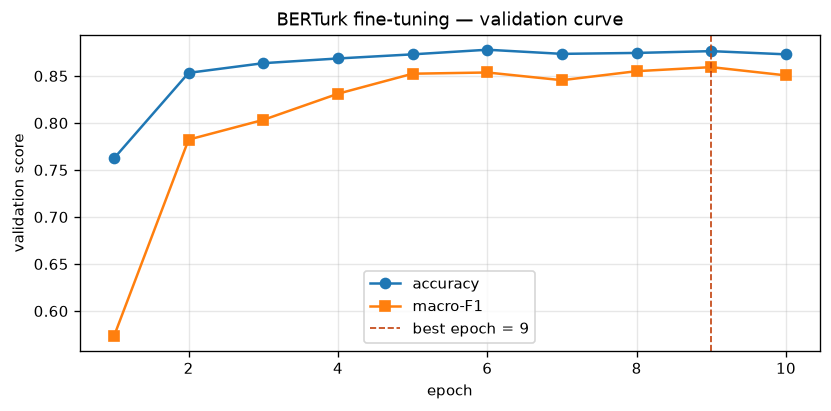

best validation macro-F1: 0.8595 at epoch 9


In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(history["epoch"], history["eval_accuracy"], marker="o", label="accuracy")
ax.plot(history["epoch"], history["eval_macro_f1"], marker="s", label="macro-F1")
best = history.loc[history["eval_macro_f1"].idxmax()]
ax.axvline(best["epoch"], color="#c2410c", ls="--", lw=1,
           label=f"best epoch = {best['epoch']:.0f}")
ax.set_xlabel("epoch")
ax.set_ylabel("validation score")
ax.set_title("BERTurk fine-tuning — validation curve")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "berturk_validation_curve.png",
            bbox_inches="tight")
plt.show()

print(f"best validation macro-F1: {best['eval_macro_f1']:.4f} at epoch {best['epoch']:.0f}")

## 4. Test-set evaluation

`load_best_model_at_end` means the weights in `trainer` are the best-on-validation
checkpoint, so the test set is touched exactly once, by a model chosen without looking at it.

In [11]:
prediction = trainer.predict(encoded["test"])
y_pred = [LABELS[i] for i in np.asarray(prediction.predictions).argmax(axis=-1)]
y_true = splits["test"]["intent"].tolist()

scored = compute_metrics(y_true, y_pred, LABELS)

print(f"test utterances     : {scored['n_examples']:,}")
print(f"accuracy            : {scored['accuracy']:.4f}")
print(f"macro-F1 (59 present): {scored['macro_f1']:.4f}")
print(f"macro-F1 (all 60)   : {scored['macro_f1_all_labels']:.4f}")
print(f"weighted-F1         : {scored['weighted_f1']:.4f}")
print(f"absent from test    : {scored['label_space']['absent_from_split']}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


test utterances     : 2,974
accuracy            : 0.8773
macro-F1 (59 present): 0.8501
macro-F1 (all 60)   : 0.8359
weighted-F1         : 0.8773
absent from test    : ['cooking_query']


The gap between the two macro-F1 numbers is the arithmetic cost of the empty class, not a
property of the model — which is exactly why the convention has to be stated rather than
left implicit.

In [12]:
worst = pd.DataFrame(scored["per_class"]).head(12)
print("Worst 12 intents by F1:")
print(worst.to_string(index=False))

Worst 12 intents by F1:
            intent  precision  recall     f1  support
   iot_hue_lighton     0.3333  0.6667 0.4444        3
     general_greet     0.3333  1.0000 0.5000        1
  email_addcontact     0.5714  0.6667 0.6154       12
    general_quirky     0.7172  0.6154 0.6624      169
    music_settings     0.6667  0.6667 0.6667        6
    takeaway_order     0.6957  0.7273 0.7111       22
  datetime_convert     0.7692  0.6667 0.7143       15
       iot_wemo_on     0.6667  0.8000 0.7273       10
audio_volume_other     0.8000  0.6667 0.7273        6
 music_dislikeness     0.7500  0.7500 0.7500        4
   audio_volume_up     0.6875  0.8462 0.7586       13
email_querycontact     0.7241  0.8077 0.7636       26


In [13]:
print("Most frequent confusions (gold -> predicted):")
for row in scored["top_confusions"]:
    print(f"  {row['count']:>3}  {row['gold']}  ->  {row['predicted']}")

Most frequent confusions (gold -> predicted):
   16  general_quirky  ->  qa_factoid
   10  calendar_set  ->  calendar_query
    9  general_quirky  ->  calendar_query
    8  calendar_query  ->  calendar_set
    7  general_quirky  ->  news_query
    7  qa_factoid  ->  general_quirky
    5  news_query  ->  general_quirky
    5  play_radio  ->  play_music
    5  transport_ticket  ->  transport_query
    5  qa_definition  ->  general_quirky
    4  play_music  ->  music_likeness
    4  play_music  ->  play_audiobook
    4  general_quirky  ->  qa_definition
    4  general_quirky  ->  recommendation_locations
    4  calendar_set  ->  calendar_remove


Per-class F1 against the number of training examples. The relationship here is the whole
argument for reporting macro-F1: if the low scores sit on the left, the model is not weak
in general, it is starved on the tail.

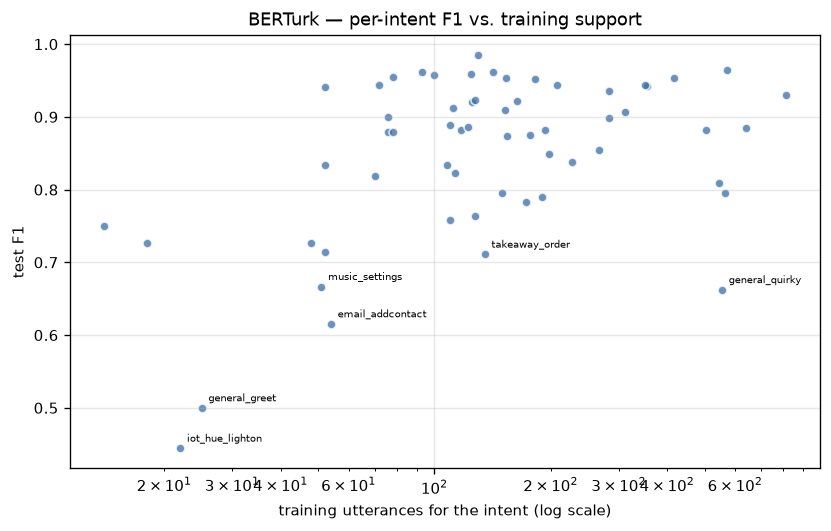

mean F1, intents with <100 train examples (17): 0.7799
mean F1, intents with >=100 train examples (42): 0.8785


In [14]:
train_support = splits["train"]["intent"].value_counts()
per_class = pd.DataFrame(scored["per_class"])
per_class["train_support"] = per_class["intent"].map(train_support).fillna(0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(per_class["train_support"], per_class["f1"], s=28, alpha=0.75,
           color="#3b6ea5", edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("training utterances for the intent (log scale)")
ax.set_ylabel("test F1")
ax.set_title("BERTurk — per-intent F1 vs. training support")
ax.grid(alpha=0.3)
for _, row in per_class.nsmallest(6, "f1").iterrows():
    ax.annotate(row["intent"], (row["train_support"], row["f1"]),
                fontsize=6, xytext=(4, 4), textcoords="offset points")
fig.tight_layout()
fig.savefig(FIG_DIR / "berturk_f1_vs_support.png",
            bbox_inches="tight")
plt.show()

rare = per_class[per_class["train_support"] < 100]
common = per_class[per_class["train_support"] >= 100]
print(f"mean F1, intents with <100 train examples ({len(rare)}): {rare['f1'].mean():.4f}")
print(f"mean F1, intents with >=100 train examples ({len(common)}): {common['f1'].mean():.4f}")

## 5. Save results

In [15]:
payload = {
    "experiment": cfg["experiment"],
    "model": cfg["model"]["name"],
    "seed": SEED,
    "config": cfg,
    "environment": env,
    "training": {
        "wall_clock_seconds": round(train_seconds, 1),
        "epochs_completed": float(history["epoch"].max()),
        "best_epoch": float(best["epoch"]),
        "best_val_macro_f1": float(best["eval_macro_f1"]),
        "final_train_loss": round(float(train_result.training_loss), 4),
        "total_parameters": int(total_params),
        "trainable_parameters": int(trainable_params),
        "fp16": USE_FP16,
    },
    "tokenizer": {
        "subword_fertility": round(float(fertility), 4),
        "max_length": MAX_LEN,
    },
    "validation_history": history.to_dict(orient="records"),
    "test": scored,
}

path = save_results(payload, cfg["output"]["results_name"],
                    results_dir=root / data_cfg["paths"]["results_dir"])
print("wrote", path)
print(f"\nHEADLINE  accuracy={scored['accuracy']:.4f}  macro-F1={scored['macro_f1']:.4f}")

wrote /Users/Alperen MacBook/turkish-intent-llm/results/berturk.json

HEADLINE  accuracy=0.8773  macro-F1=0.8501
